<h3><b>Introduction to Data Analytics - Exercise set 4, exercise 3a.</b></h3>
<h4><b>US Unemployment dataset</b></h4>
<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_4/calendar.png" />


<hr /><h1>!!!!! IMPORTANT !!!!!</h1> 

<h2>Do not use generative AI in this exercise!</h2>
<b>Remember:</b> in working life, we are not allowed to freely share our data with just any generative AI, since the data is often sensitive and owned by a client. 

Generative AIs would use the data to train themselves in the future, which is a violation of regulations.
The point of this exercise set is to <b>MANUALLY</b> inspect the plots in the examples and learn how to see trends and features in the data.
 
See also the materials discussing the usage of AI in this course!
<hr />

<b>Tip:</b> You can just click "Run All" to see the results of this notebook. Some of these exercises have some heavy plots that can take even 1 minute to produce.


<b>Remember:</b> not every dataset has interesting correlations and/or features (too much randomness or variance usually, or not enough data). Also, not each correlation implies there's a causation. Finally, not every plot is useful, that's why it's important to try multiple plots in order to "see under the hood". Typically pair plots, joint plots, regression plots, heatmaps and box plots are most useful, but there are some exceptions too.

<h3><b>Quick summary of data:</b></h3>

<p>This dataset contains unemployment rates from year 1948 to 2019 in the USA.</p>
<p>This notebook is a perfect example why pivot tables and heatmaps are so important. It also demonstrates the fantastic feature in pandas called "melt".</p>
<p>Kaggle page: <a href="https://www.kaggle.com/datasets/tunguz/us-monthly-unemployment-rate-1948-present">https://www.kaggle.com/datasets/tunguz/us-monthly-unemployment-rate-1948-present</a></p>

<h3><b>Questions for this exercise:</b></h3>
<b>Answer the questions either as code comments or as markdown. Use separate cells to write your answers.</b><br/><br/>
<li>You should see two extensive unemployment periods in the dataset. What are these years, and can find you any info by using Google on these years in US unemployment?</li>
<li>Which seaborn plots are useful in this notebook, and which are not? Why? (you can remove the unnecessary plots from this notebook if you wish too).</li>
<li>Which are more useful in this case, correlations or plots? Or are they both useful?</li>

<b>Extra questions/tasks for extra points:</b>
<li>Any other ideas about this dataset? Any ways to expand or improve the dataset and the analysis?</li>


<hr />

# Basic Questions

<div style="border: 3px dashed white; padding: 10px;"> 
<h3>Question 1</h3>

You should see two extensive unemployment periods in the dataset. What are these years, and can find you any info by using Google on these years in US unemployment?

<h3> Answer </h3>

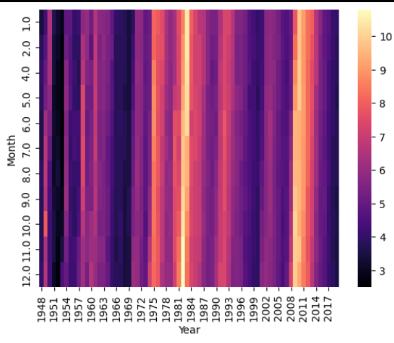

1982 and 2008 are key years here. These are both recessions. 

#### 2009 Great Recession 

Most of us have experienced the Great Recession in some way as it was worldwide. The US housing market crash caused shockwaves all around the world, <strong style='color:red'>largely caused by predatory loans from US Banks, toxic assets, the collapse of home prices, and overabundance of consumer debt for buyers with a non-fixed interest rates for mortgages. </strong>

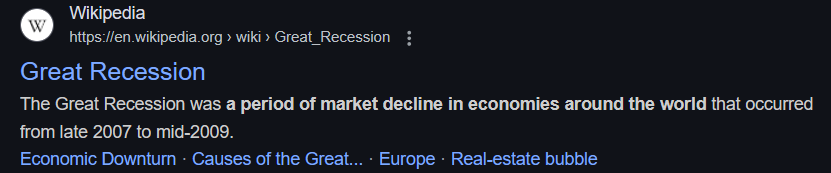


#### 1980's Recession

This was largely caused by the US national effort of tring to fight unemployment via higher inflation (see the Phillips Curve) and using a 'Stop-go' policy, which basically means to make the US Federal interest rate high or low depending on money flow and economic conditions. This caused a lot of insecurity for investors in the market, which led to a market crash and extended recession.

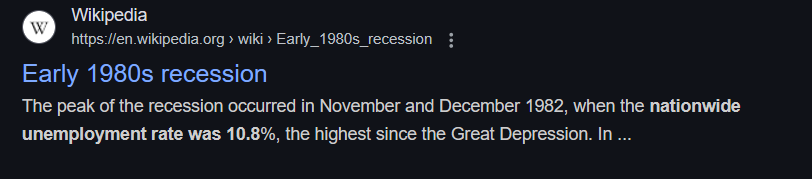
</div>

<div style="border: 3px dashed white; padding: 10px;"> 
<h3>Question 2</h3>

Which seaborn plots are useful in this notebook, and which are not? Why? (you can remove the unnecessary plots from this notebook if you wish too).

<h3> Answer </h3>


The numbers are crunched together and <strong style='color:red'> correlating months between other months doesn't gain much insight </strong> 

Not as useful.

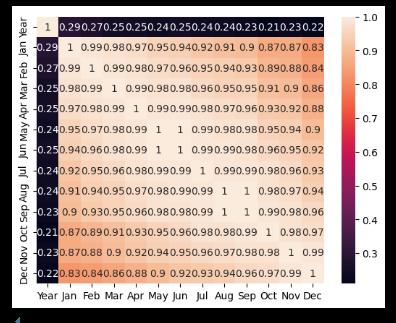

Same situation here. We could correlate here maybe that <strong style='color:red'>values go up as years progress</strong> but that <strong style='color:red'> there is a negative correlation between months and values. </strong> But we cannot extrapolite as to why yet. A plot would be more useful for this.

Not as useful.

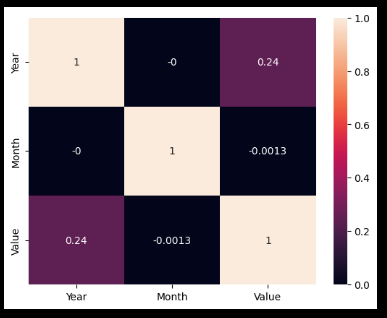

I do like the idea of having doing distributions at the same time as a scatterplot, but maybe it would be better with hue! It does show somewhat of a positive trend, which is useful to know.

Not as useful.

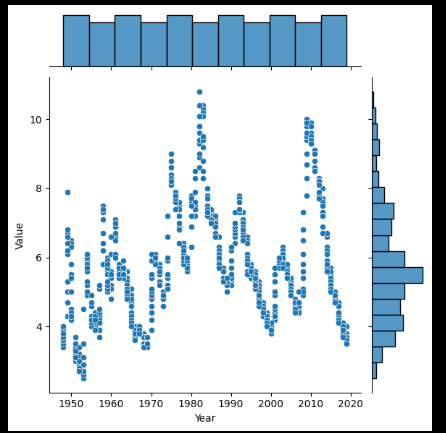


This is better. We can notice that bottom unemployment values are typically between months 10-12. We can also see some noticeable peaks and unemployment values. We can also be less suspicious of seasonality because the colors are peppered and scattered. It is a shame the jointplot doesn't cover the whole canvas, but that's all not necessary to get insight from it.

<strong style='color:red'> Useful </strong>

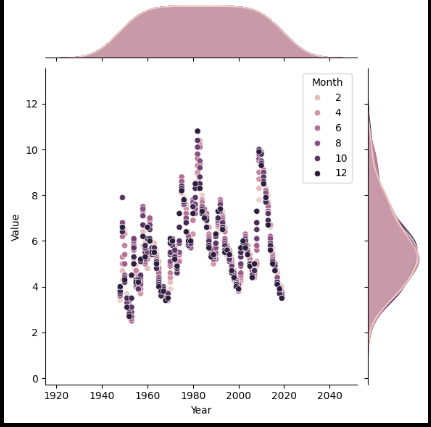

We can clearly see which month and years high values and which have low values. We can easily make hypotheses and see which dates to look. This is a gem!

<strong style='color:red'> Extremely useful </strong>

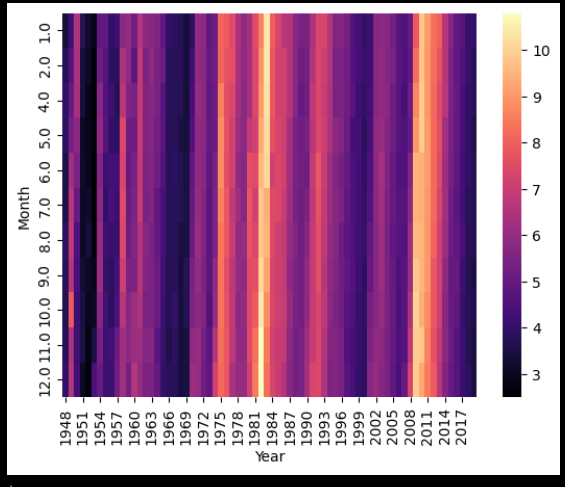
</div>

<div style="border: 3px dashed white; padding: 10px;"> 
<h3>Question 3</h3>

Which are more useful in this case, correlations or plots? Or are they both useful?

Plots. By far. 

The two most useful plots are the heatplot at the end and the jointplot with hue. 

The correlation plots show correlations between months and year, which is silly!

</div>

---

# Extra Questions

<div style="border: 3px dashed white; padding: 10px;"> 
<h3>Question 1</h3>

Any other ideas about this dataset? Any ways to expand or improve the dataset and the analysis?

</div>

<hr />

<h4><b>Imports and load the original dataset</b></h4>

In [4]:
# import the common data analytics modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# disable scientific notation in pandas
pd.set_option('display.float_format', lambda x: '%.2f' % x)

<h4><b>Helper functions for dataset cleaning</b></h4>

In [5]:
# helper function for pandas to convert string format month names to a corresponding number
# numbers are much more useful when it comes to heatmaps, since it puts the months in order
# note: a more neat way to do this would be use the value mapping feature in pandas
def month_to_numeric(row):
    month = row['Month']

    # map the needed month
    if month == "Jan":
        return 1
    elif month == "Feb":
        return 2
    elif month == "Feb":
        return 3
    elif month == "Mar":
        return 4
    elif month == "Apr":
        return 5
    elif month == "Jun":
        return 6
    elif month == "Jul":
        return 7
    elif month == "Aug":
        return 8
    elif month == "Sep":
        return 9
    elif month == "Oct":
        return 10
    elif month == "Nov":
        return 11
    elif month == "Dec":
        return 12

<h4><b>Processing data</b></h4>

In [6]:
# read the dataset and create a correlation matrix
df = pd.read_csv("USUnemployment.csv")
correlations = df.corr().round(2)

# this function in pandas is called "melt", and it's one of
# the more impressive features in pandas. with loops, this would be
# a tedious operation to be done

# here's an example what melt-function does:

# original DataFrame:
# Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
# 1948,3.4,3.8,4.0,3.9,3.5,3.6,3.6,3.9,3.8,3.7,3.8,4.0
# 1949,4.3,4.7,5.0,5.3,6.1,6.2,6.7,6.8,6.6,7.9,6.4,6.6
# 1950,6.5,6.4,6.3,5.8,5.5,5.4,5.0,4.5,4.4,4.2,4.2,4.3

# after melt, the format is this:
# Year, Month,  Value
# 1948, 1,      3.4
# 1949, 1,      4.3
# 1950, 1,      6.5

# and so on. you can use the Data Viewer to compare df and df2
# remember the melt-function every time you have TimeSeries -data,
# but it's not yet very compatible for pivot table and heatmap

df2 = df.melt(id_vars=["Year"], 
             var_name="Month",
             value_name="Value")

# convert year to integer (better for heatmaps)
# also switch month string format to an integer by using the helper function (see code above)
df2['Year'] = df2['Year'].astype(int)
df2['Month'] = df2.apply(month_to_numeric, axis=1)

# create pivot table for a later heatmap
pt = df2.pivot_table(index='Month', columns='Year', values='Value')

<h4><b>seaborn plots - heatmaps for correlations matrices</b></h4>

<Axes: >

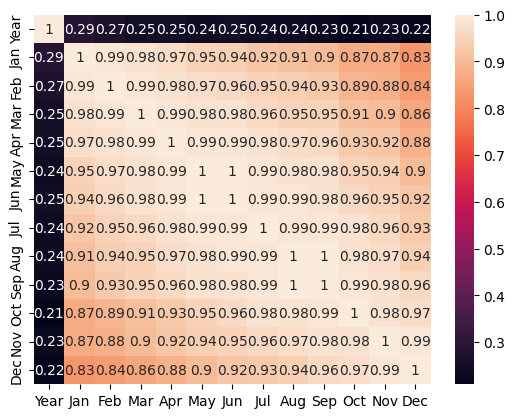

In [7]:
# basic heatmap for original data correlation matrix
sns.heatmap(correlations, annot=True)

<Axes: >

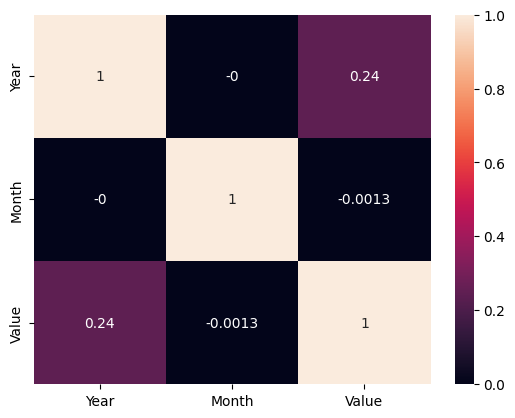

In [8]:
# basic heatmap for melted correlation matrix
sns.heatmap(df2.corr().round(4), annot=True)

<h4><b>seaborn plots - joint plots and pivot table heatmap</b></h4>

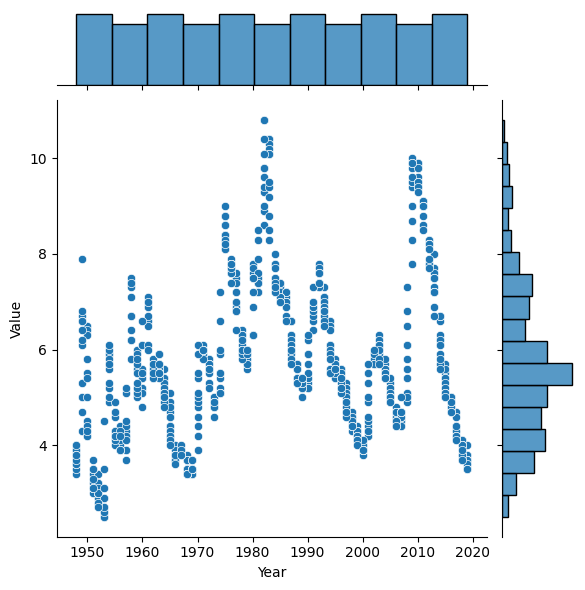

In [9]:
# basic joint plot for unemployment value and year
sns.jointplot(x='Year', y='Value', data=df2)

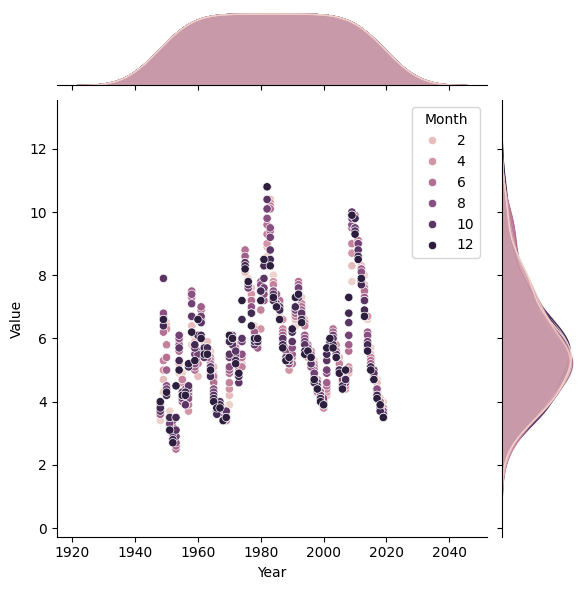

In [10]:
# basic joint plot for unemployment value and year, hue on month
sns.jointplot(x='Year', y='Value', data=df2, hue='Month')

<Axes: xlabel='Year', ylabel='Month'>

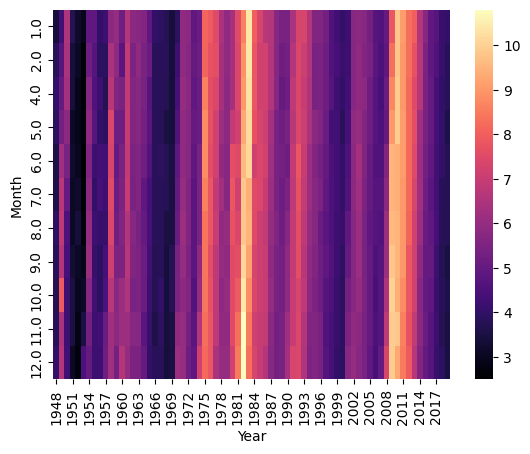

In [11]:
# heatmap for pivot table
sns.heatmap(pt, cmap='magma') 